# BirdCLEF 2026: Dataset Preparation + Audio Preprocessing

This notebook covers the first two project steps only:

1. **Dataset preparation**: verify the dataset files, load metadata, build the 234-class label map, and create training manifests.
2. **Audio preprocessing**: load `.ogg` files, resample them, cut/pad 5-second windows, and convert them to log-mel spectrograms.

There are no helper scripts. Everything needed for these two steps is inside this notebook.

## 0. Imports

In [1]:
from pathlib import Path
import ast
import json
import math
import os
import platform
import random
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Torch:", torch.__version__)

Python: 3.11.4
Platform: Windows-10-10.0.19045-SP0
Torch: 2.11.0+cu128


## 1. GPU / CPU Detection

Run this near the top of every training notebook. If `torch.cuda.is_available()` is `False`, the notebook is using CPU even if the computer has an NVIDIA GPU.

In [2]:
print("CUDA available to PyTorch:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA version used by PyTorch:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        total_gb = props.total_memory / 1024**3
        print(f"GPU {i}: {props.name} | {total_gb:.2f} GB VRAM")
else:
    device = torch.device("cpu")
    print("Using CPU. If you expected GPU, install a CUDA-enabled PyTorch build and select a GPU kernel/runtime.")

try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    if result.returncode == 0:
        print("\n--- nvidia-smi ---")
        print("\n".join(result.stdout.splitlines()[:18]))
    else:
        print("nvidia-smi ran but did not return successfully:", result.stderr[:300])
except Exception as exc:
    print("nvidia-smi is not available in this environment:", repr(exc))

device

CUDA available to PyTorch: True
CUDA version used by PyTorch: 12.8
GPU count: 1
GPU 0: NVIDIA GeForce RTX 3060 | 12.00 GB VRAM

--- nvidia-smi ---
Tue Jun  2 15:05:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   55C    P8             25W /  170W |     277MiB /  12288MiB |     13%      Def

device(type='cuda')

## 2. Locate and Check the Dataset

The local folder should be named `birdclef-2026`. The notebook also checks the typo `birdcle-2026` and Kaggle input paths.

In [3]:
def find_dataset_dir():
    names = ["birdclef-2026", "birdcle-2026"]
    candidates = []

    env_dir = os.environ.get("BIRDCLEF_DATA_DIR")
    if env_dir:
        candidates.append(Path(env_dir))

    for base in [Path.cwd(), Path.cwd().parent, Path("/kaggle/input")]:
        for name in names:
            candidates.append(base / name)

    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate.resolve()

    checked = "\n".join(str(c) for c in candidates)
    raise FileNotFoundError(f"Could not find BirdCLEF dataset folder. Checked:\n{checked}")


DATA_DIR = find_dataset_dir()
WORK_DIR = Path.cwd() / "birdclef_work"
WORK_DIR.mkdir(exist_ok=True)

print("Dataset directory:", DATA_DIR)
print("Notebook output directory:", WORK_DIR)

Dataset directory: D:\BirdCLEF+\birdclef-2026
Notebook output directory: d:\BirdCLEF+\birdclef_work


In [4]:
required_paths = {
    "taxonomy": DATA_DIR / "taxonomy.csv",
    "train_metadata": DATA_DIR / "train.csv",
    "train_soundscape_labels": DATA_DIR / "train_soundscapes_labels.csv",
    "sample_submission": DATA_DIR / "sample_submission.csv",
    "train_audio_dir": DATA_DIR / "train_audio",
    "train_soundscapes_dir": DATA_DIR / "train_soundscapes",
    "test_soundscapes_dir": DATA_DIR / "test_soundscapes",
}

missing = [name for name, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required dataset items: {missing}")

rows = []
for name, path in required_paths.items():
    if path.is_dir():
        files = list(path.rglob("*"))
        file_count = sum(1 for p in files if p.is_file())
        size_gb = sum(p.stat().st_size for p in files if p.is_file()) / 1024**3
        rows.append({"name": name, "type": "directory", "files": file_count, "size_gb": round(size_gb, 3), "path": str(path)})
    else:
        rows.append({"name": name, "type": "file", "files": 1, "size_gb": round(path.stat().st_size / 1024**3, 6), "path": str(path)})

dataset_check = pd.DataFrame(rows)
dataset_check

,name,type,files,size_gb,path
0,taxonomy,file,1,0.000013,D:\BirdCLEF+\birdclef-2026\taxonomy.csv
1,train_metadata,file,1,0.006314,D:\BirdCLEF+\birdclef-2026\train.csv
2,train_soundscape_labels,file,1,0.000125,D:\BirdCLEF+\birdclef-2026\train_soundscapes_labels.csv
3,sample_submission,file,1,0.000016,D:\BirdCLEF+\birdclef-2026\sample_submission.csv
4,train_audio_dir,directory,35549,10.016000,D:\BirdCLEF+\birdclef-2026\train_audio
5,train_soundscapes_dir,directory,10658,5.008000,D:\BirdCLEF+\birdclef-2026\train_soundscapes
6,test_soundscapes_dir,directory,1,0.000000,D:\BirdCLEF+\birdclef-2026\test_soundscapes


## 3. Load Metadata

In [5]:
taxonomy = pd.read_csv(DATA_DIR / "taxonomy.csv", dtype={"primary_label": str, "inat_taxon_id": str})
train = pd.read_csv(DATA_DIR / "train.csv", dtype={"primary_label": str, "inat_taxon_id": str})
soundscape_labels = pd.read_csv(DATA_DIR / "train_soundscapes_labels.csv", dtype={"primary_label": str})
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

target_labels = [c for c in sample_submission.columns if c != "row_id"]

print("taxonomy rows:", len(taxonomy))
print("train metadata rows:", len(train))
print("soundscape label rows:", len(soundscape_labels))
print("submission target columns:", len(target_labels))

display(taxonomy.head())
display(train.head())
display(soundscape_labels.head())

taxonomy rows: 234
train metadata rows: 35549
soundscape label rows: 1478
submission target columns: 234


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197.mp3?1727581626,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648.mp3?1719714347,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.mp3?1694395513,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.mp3?1695610958,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.mp3?1667105088,1161364/iNat556514.ogg,iNat


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


## 4. Build the 234-Class Label Map

Use the `sample_submission.csv` columns as the final target order. This is the safest order because the submission must match these columns exactly.

In [6]:
taxonomy_labels = set(taxonomy["primary_label"].astype(str))
sample_labels = set(target_labels)

assert taxonomy_labels == sample_labels, "taxonomy.csv labels and sample_submission.csv columns do not match."

label_to_index = {label: i for i, label in enumerate(target_labels)}
index_to_label = {i: label for label, i in label_to_index.items()}

label_map = taxonomy.set_index("primary_label").loc[target_labels].reset_index()
label_map.insert(0, "class_index", range(len(label_map)))

label_map_path = WORK_DIR / "label_map.csv"
label_map.to_csv(label_map_path, index=False)

print("Saved:", label_map_path)
print("Number of targets:", len(label_map))
display(label_map.head(10))
display(label_map["class_name"].value_counts().rename_axis("class_name").reset_index(name="target_count"))

Saved: d:\BirdCLEF+\birdclef_work\label_map.csv
Number of targets: 234


,class_index,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia
5,5,209233,209233,Equus caballus,Feral Horse,Mammalia
6,6,22930,22930,Leptodactylus syphax,Basin White-lipped Frog,Amphibia
7,7,22956,22956,Leptodactylus mystacinus,Mustached Frog,Amphibia
8,8,22961,22961,Leptodactylus podicipinus,Pointedbelly Frog,Amphibia
9,9,22967,22967,Leptodactylus elenae,Marbled White-lipped Frog,Amphibia


,class_name,target_count
0,Aves,162
1,Amphibia,35
2,Insecta,28
3,Mammalia,8
4,Reptilia,1


## 5. Create the `train_audio` Manifest

`train_audio` clips are curated recordings. Most rows have one primary label. Secondary labels may exist, so we keep a `labels` field and a 234-length multi-hot target.

In [7]:
def parse_list_cell(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text in {"", "[]"}:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    return [text]


def labels_to_multihot(labels):
    y = np.zeros(len(target_labels), dtype=np.uint8)
    for label in labels:
        label = str(label)
        if label in label_to_index:
            y[label_to_index[label]] = 1
    return y


train_audio_manifest = train.copy()
train_audio_manifest["primary_label"] = train_audio_manifest["primary_label"].astype(str)
train_audio_manifest["secondary_label_list"] = train_audio_manifest["secondary_labels"].apply(parse_list_cell)
train_audio_manifest["labels"] = train_audio_manifest.apply(
    lambda r: sorted(set([r["primary_label"]] + r["secondary_label_list"])), axis=1
)
train_audio_manifest["primary_index"] = train_audio_manifest["primary_label"].map(label_to_index)
train_audio_manifest["audio_path"] = train_audio_manifest["filename"].apply(lambda x: str(DATA_DIR / "train_audio" / x))
train_audio_manifest["file_exists"] = train_audio_manifest["audio_path"].apply(lambda x: Path(x).exists())
train_audio_manifest["labels_string"] = train_audio_manifest["labels"].apply(lambda labels: ";".join(labels))
train_audio_manifest["positive_count"] = train_audio_manifest["labels"].apply(len)

missing_audio = int((~train_audio_manifest["file_exists"]).sum())
if missing_audio:
    print("WARNING: missing train_audio files:", missing_audio)
else:
    print("All train_audio files referenced by train.csv exist.")

audio_manifest_path = WORK_DIR / "train_audio_manifest.csv"
columns_to_save = [
    "filename", "audio_path", "file_exists", "primary_label", "primary_index", "labels_string",
    "positive_count", "scientific_name", "common_name", "class_name", "collection", "rating", "license", "url",
]
train_audio_manifest[columns_to_save].to_csv(audio_manifest_path, index=False)

print("Saved:", audio_manifest_path)
print("Rows:", len(train_audio_manifest))
print("Unique primary labels in train.csv:", train_audio_manifest["primary_label"].nunique())
display(train_audio_manifest[columns_to_save].head())

All train_audio files referenced by train.csv exist.
Saved: d:\BirdCLEF+\birdclef_work\train_audio_manifest.csv
Rows: 35549
Unique primary labels in train.csv: 206


,filename,audio_path,file_exists,primary_label,primary_index,labels_string,positive_count,scientific_name,common_name,class_name,collection,rating,license,url
0,1161364/iNat1216197.ogg,D:\BirdCLEF+\birdclef-2026\train_audio\1161364\iNat1216197.ogg,True,1161364,0,1161364,1,Guyalna cuta,Guyalna cuta,Insecta,iNat,0.0,cc-by-nc,https://static.inaturalist.org/sounds/1216197.mp3?1727581626
1,1161364/iNat1114648.ogg,D:\BirdCLEF+\birdclef-2026\train_audio\1161364\iNat1114648.ogg,True,1161364,0,1161364,1,Guyalna cuta,Guyalna cuta,Insecta,iNat,0.0,cc-by-nc,https://static.inaturalist.org/sounds/1114648.mp3?1719714347
2,1161364/iNat810195.ogg,D:\BirdCLEF+\birdclef-2026\train_audio\1161364\iNat810195.ogg,True,1161364,0,1161364,1,Guyalna cuta,Guyalna cuta,Insecta,iNat,0.0,cc-by-nc,https://static.inaturalist.org/sounds/810195.mp3?1694395513
3,1161364/iNat818781.ogg,D:\BirdCLEF+\birdclef-2026\train_audio\1161364\iNat818781.ogg,True,1161364,0,1161364,1,Guyalna cuta,Guyalna cuta,Insecta,iNat,0.0,cc-by-nc,https://static.inaturalist.org/sounds/818781.mp3?1695610958
4,1161364/iNat556514.ogg,D:\BirdCLEF+\birdclef-2026\train_audio\1161364\iNat556514.ogg,True,1161364,0,1161364,1,Guyalna cuta,Guyalna cuta,Insecta,iNat,0.0,cc-by-nc,https://static.inaturalist.org/sounds/556514.mp3?1667105088


In [8]:
train_label_counts = (
    train_audio_manifest.groupby(["primary_label", "common_name", "class_name"])
    .size()
    .reset_index(name="clip_count")
    .sort_values("clip_count")
)

print("Least represented primary labels:")
display(train_label_counts.head(15))

print("Most represented primary labels:")
display(train_label_counts.tail(15).sort_values("clip_count", ascending=False))

Least represented primary labels:


,primary_label,common_name,class_name,clip_count
1,116570,Southern Spectacled Caiman,Reptilia,1
12,23150,Central Dwarf Frog,Amphibia,1
29,516975,Hooded Capuchin,Mammalia,1
16,23724,Waxy Monkey Tree Frog,Amphibia,1
4,209233,Feral Horse,Mammalia,2
20,24321,Mato Grosso Snouted Tree Frog,Amphibia,2
39,70711,Cei's White-lipped Frog,Amphibia,2
23,25214,Muller's Termite Frog,Amphibia,3
30,555123,Usina Tree Frog,Amphibia,3
42,74580,Black-tailed Marmoset,Mammalia,3


Most represented primary labels:


,primary_label,common_name,class_name,clip_count
142,rubthr1,Rufous-bellied Thrush,Aves,499
48,banana,Bananaquit,Aves,498
170,soulap1,Southern Lapwing,Aves,497
83,fepowl,Ferruginous Pygmy Owl,Aves,497
103,houspa,House Sparrow,Aves,496
121,osprey,Osprey,Aves,495
74,coffal1,Collared Forest-Falcon,Aves,495
167,socfly1,Social Flycatcher,Aves,494
75,compau,Pauraque,Aves,493
205,yeofly1,Yellow-olive Flatbill,Aves,493


## 6. Create the Labeled Soundscape Window Manifest

These rows are already in the same 5-second-window style as the final submission. The `primary_label` column can contain multiple labels separated by semicolons.

In [9]:
def hhmmss_to_seconds(value):
    parts = str(value).split(":")
    if len(parts) != 3:
        raise ValueError(f"Expected HH:MM:SS, got {value!r}")
    hours, minutes, seconds = [int(x) for x in parts]
    return hours * 3600 + minutes * 60 + seconds


def parse_semicolon_labels(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [x for x in text.split(";") if x]


soundscape_manifest = soundscape_labels.copy()
soundscape_manifest["labels"] = soundscape_manifest["primary_label"].apply(parse_semicolon_labels)
soundscape_manifest["labels_string"] = soundscape_manifest["labels"].apply(lambda labels: ";".join(labels))
soundscape_manifest["positive_count"] = soundscape_manifest["labels"].apply(len)
soundscape_manifest["start_seconds"] = soundscape_manifest["start"].apply(hhmmss_to_seconds)
soundscape_manifest["end_seconds"] = soundscape_manifest["end"].apply(hhmmss_to_seconds)
soundscape_manifest["duration_seconds"] = soundscape_manifest["end_seconds"] - soundscape_manifest["start_seconds"]
soundscape_manifest["audio_path"] = soundscape_manifest["filename"].apply(lambda x: str(DATA_DIR / "train_soundscapes" / x))
soundscape_manifest["file_exists"] = soundscape_manifest["audio_path"].apply(lambda x: Path(x).exists())

assert soundscape_manifest["duration_seconds"].eq(5).all(), "Expected every labeled soundscape row to be a 5-second window."

missing_soundscapes = int((~soundscape_manifest["file_exists"]).sum())
if missing_soundscapes:
    print("WARNING: missing labeled train_soundscapes files:", missing_soundscapes)
else:
    print("All labeled train_soundscapes files exist.")

multi_hot = np.stack(soundscape_manifest["labels"].apply(labels_to_multihot).to_numpy())
multi_hot_df = pd.DataFrame(multi_hot, columns=target_labels)

soundscape_windows = pd.concat(
    [
        soundscape_manifest[[
            "filename", "audio_path", "file_exists", "start", "end", "start_seconds", "end_seconds",
            "duration_seconds", "labels_string", "positive_count",
        ]].reset_index(drop=True),
        multi_hot_df,
    ],
    axis=1,
)

soundscape_windows_path = WORK_DIR / "train_soundscape_windows.csv"
soundscape_windows.to_csv(soundscape_windows_path, index=False)

print("Saved:", soundscape_windows_path)
print("Rows:", len(soundscape_windows))
print("Unique labeled soundscape files:", soundscape_manifest["filename"].nunique())
print("Unique labels appearing in labeled soundscape windows:", len(set(sum(soundscape_manifest["labels"].tolist(), []))))
display(soundscape_windows.head())

All labeled train_soundscapes files exist.
Saved: d:\BirdCLEF+\birdclef_work\train_soundscape_windows.csv
Rows: 1478
Unique labeled soundscape files: 66
Unique labels appearing in labeled soundscape windows: 75


,filename,audio_path,file_exists,start,end,start_seconds,end_seconds,duration_seconds,labels_string,positive_count,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,22967,22973,22983,22985,23150,23154,23158,23176,23724,24279,24285,24287,24321,244024,25073,25092,25214,326272,41970,43435,47144,...,sobtyr1,socfly1,sofspi1,souant1,soulap1,souscr1,spbant3,spispi1,sptnig1,squcuc1,stbwoo2,strcuc1,strher2,strowl1,swthum1,swtman1,tattin1,thlwre1,toctou1,trokin,trsowl,undtin1,varant1,watjac1,wesfie1,wfwduc1,whbant2,whbwar2,whiwoo1,whlspi1,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Train_0039_S22_20211231_201500.ogg,D:\BirdCLEF+\birdclef-2026\train_soundscapes\BC2026_Train_0039_S22_20211231_201500.ogg,True,00:00:00,00:00:05,0,5,5,22961;23158;24321;517063;65380,5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,BC2026_Train_0039_S22_20211231_201500.ogg,D:\BirdCLEF+\birdclef-2026\train_soundscapes\BC2026_Train_0039_S22_20211231_201500.ogg,True,00:00:05,00:00:10,5,10,5,22961;23158;24321;517063;65380,5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,BC2026_Train_0039_S22_20211231_201500.ogg,D:\BirdCLEF+\birdclef-2026\train_soundscapes\BC2026_Train_0039_S22_20211231_201500.ogg,True,00:00:10,00:00:15,10,15,5,22961;23158;24321;517063;65380,5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,BC2026_Train_0039_S22_20211231_201500.ogg,D:\BirdCLEF+\birdclef-2026\train_soundscapes\BC2026_Train_0039_S22_20211231_201500.ogg,True,00:00:15,00:00:20,15,20,5,22961;23158;24321;517063;65380,5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,BC2026_Train_0039_S22_20211231_201500.ogg,D:\BirdCLEF+\birdclef-2026\train_soundscapes\BC2026_Train_0039_S22_20211231_201500.ogg,True,00:00:20,00:00:25,20,25,5,22961;23158;24321;517063;65380,5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
soundscape_positive_counts = pd.Series(sum(soundscape_manifest["labels"].tolist(), [])).value_counts()
soundscape_positive_counts = (
    soundscape_positive_counts.rename_axis("primary_label")
    .reset_index(name="positive_window_count")
    .merge(label_map[["primary_label", "common_name", "class_name"]], on="primary_label", how="left")
)

display(soundscape_manifest.groupby("filename").size().reset_index(name="labeled_windows").head(10))
display(soundscape_positive_counts.head(20))

,filename,labeled_windows
0,BC2026_Train_0001_S08_20250606_030007.ogg,24
1,BC2026_Train_0002_S08_20250607_030007.ogg,24
2,BC2026_Train_0003_S08_20250607_070007.ogg,24
3,BC2026_Train_0004_S08_20250607_070007.ogg,24
4,BC2026_Train_0005_S08_20250607_070007.ogg,24
5,BC2026_Train_0006_S09_20250828_000000.ogg,4
6,BC2026_Train_0007_S09_20250829_000000.ogg,16
7,BC2026_Train_0008_S09_20250831_000000.ogg,10
8,BC2026_Train_0009_S09_20250828_000000.ogg,4
9,BC2026_Train_0010_S09_20250828_000000.ogg,4


,primary_label,positive_window_count,common_name,class_name
0,65380,666,Dwarf Tree Frog,Amphibia
1,517063,626,Southern Orange-legged Leaf Frog,Amphibia
2,22973,426,Whistling Grass Frog,Amphibia
3,555146,420,Chaco Tree Frog,Amphibia
4,23158,350,Pale-legged Weeping Frog,Amphibia
5,24279,346,Lesser Snouted Tree Frog,Amphibia
6,24321,344,Mato Grosso Snouted Tree Frog,Amphibia
7,22967,310,Marbled White-lipped Frog,Amphibia
8,66971,298,Paraguayan Swimming Frog,Amphibia
9,47158son25,168,Insect sonotype25,Insecta


## 7. Audio Backend Check

To read `.ogg` audio, this notebook needs either `librosa` or `torchaudio`. Kaggle notebooks usually include an audio backend. If this local environment has neither, the metadata preparation still works, but the log-mel cells will print a clear message.

In [11]:
AUDIO_BACKEND = None

try:
    import librosa
    AUDIO_BACKEND = "librosa"
    print("Audio backend: librosa", librosa.__version__)
except Exception as librosa_exc:
    librosa = None
    try:
        import torchaudio
        AUDIO_BACKEND = "torchaudio"
        print("Audio backend: torchaudio", torchaudio.__version__)
    except Exception as torchaudio_exc:
        torchaudio = None
        print("No .ogg audio backend found.")
        print("librosa error:", repr(librosa_exc))
        print("torchaudio error:", repr(torchaudio_exc))
        print("Install librosa+soundfile or torchaudio before running the audio preprocessing cells.")

AUDIO_BACKEND

Audio backend: librosa 0.11.0


'librosa'

## 8. Audio Preprocessing Configuration

These settings are a strong starting point for BirdCLEF-style models.

In [12]:
TARGET_SR = 32_000
CLIP_SECONDS = 5
CLIP_SAMPLES = TARGET_SR * CLIP_SECONDS

N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
FMIN = 20
FMAX = TARGET_SR // 2

print({
    "target_sr": TARGET_SR,
    "clip_seconds": CLIP_SECONDS,
    "clip_samples": CLIP_SAMPLES,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "n_mels": N_MELS,
    "fmin": FMIN,
    "fmax": FMAX,
})

{'target_sr': 32000, 'clip_seconds': 5, 'clip_samples': 160000, 'n_fft': 2048, 'hop_length': 512, 'n_mels': 128, 'fmin': 20, 'fmax': 16000}


In [13]:
def pad_or_trim(y, target_len=CLIP_SAMPLES):
    y = np.asarray(y, dtype=np.float32)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        y = y[:target_len]
    return y


def load_audio(path, offset_seconds=0.0, duration_seconds=CLIP_SECONDS, target_sr=TARGET_SR):
    path = Path(path)
    if AUDIO_BACKEND == "librosa":
        y, sr = librosa.load(
            path,
            sr=target_sr,
            mono=True,
            offset=float(offset_seconds),
            duration=float(duration_seconds),
        )
        return pad_or_trim(y, int(target_sr * duration_seconds))

    if AUDIO_BACKEND == "torchaudio":
        waveform, sr = torchaudio.load(str(path))
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        start = int(round(offset_seconds * sr))
        end = start + int(round(duration_seconds * sr))
        waveform = waveform[:, start:end]
        if sr != target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, target_sr)
        return pad_or_trim(waveform.squeeze(0).numpy(), int(target_sr * duration_seconds))

    raise RuntimeError("No audio backend is available. Install librosa+soundfile or torchaudio.")


def waveform_to_logmel(y, sr=TARGET_SR):
    y = np.asarray(y, dtype=np.float32)

    if AUDIO_BACKEND == "librosa":
        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
            power=2.0,
        )
        logmel = librosa.power_to_db(mel, ref=np.max)
        return logmel.astype(np.float32)

    if AUDIO_BACKEND == "torchaudio":
        waveform = torch.tensor(y, dtype=torch.float32).unsqueeze(0)
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            f_min=FMIN,
            f_max=FMAX,
            power=2.0,
        )
        db_transform = torchaudio.transforms.AmplitudeToDB(stype="power")
        logmel = db_transform(mel_transform(waveform)).squeeze(0).numpy()
        return logmel.astype(np.float32)

    raise RuntimeError("No audio backend is available. Install librosa+soundfile or torchaudio.")


def normalize_logmel(logmel):
    mean = float(logmel.mean())
    std = float(logmel.std())
    return ((logmel - mean) / (std + 1e-6)).astype(np.float32)

## 9. Test Preprocessing on One `train_audio` Clip

Example file: purjay1/XC299441.ogg
Primary label: purjay1 | Purplish Jay
Waveform shape: (160000,)
Log-mel shape: (128, 313)


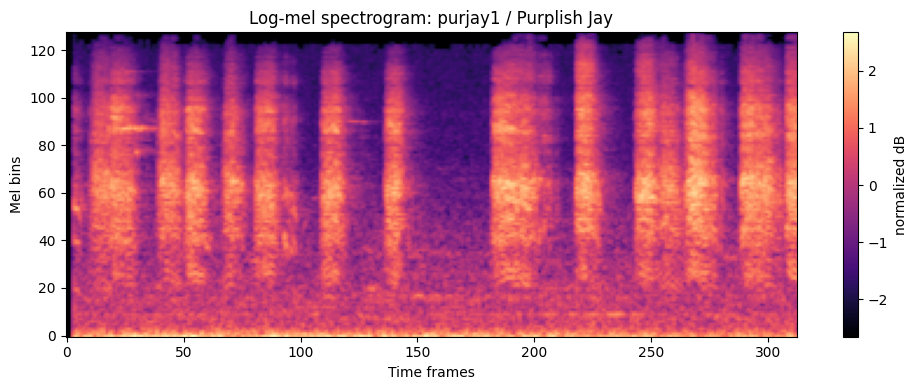

In [14]:
if AUDIO_BACKEND is None:
    print("Skipping audio preprocessing demo because no audio backend is installed.")
else:
    example_audio_row = train_audio_manifest[train_audio_manifest["file_exists"]].sample(1, random_state=SEED).iloc[0]
    y = load_audio(example_audio_row["audio_path"], offset_seconds=0, duration_seconds=CLIP_SECONDS)
    logmel = normalize_logmel(waveform_to_logmel(y))

    print("Example file:", example_audio_row["filename"])
    print("Primary label:", example_audio_row["primary_label"], "|", example_audio_row["common_name"])
    print("Waveform shape:", y.shape)
    print("Log-mel shape:", logmel.shape)

    plt.figure(figsize=(10, 4))
    plt.imshow(logmel, aspect="auto", origin="lower", cmap="magma")
    plt.title(f"Log-mel spectrogram: {example_audio_row['primary_label']} / {example_audio_row['common_name']}")
    plt.xlabel("Time frames")
    plt.ylabel("Mel bins")
    plt.colorbar(label="normalized dB")
    plt.tight_layout()
    plt.show()

## 10. Test Preprocessing on One Labeled Soundscape Window

This is the most important format because the hidden test set is also continuous soundscape audio split into 5-second windows.

Example soundscape: BC2026_Train_0024_S22_20211123_004500.ogg
Window: 00:00:15 to 00:00:20
Labels: 22967;compau
Waveform shape: (160000,)
Log-mel shape: (128, 313)


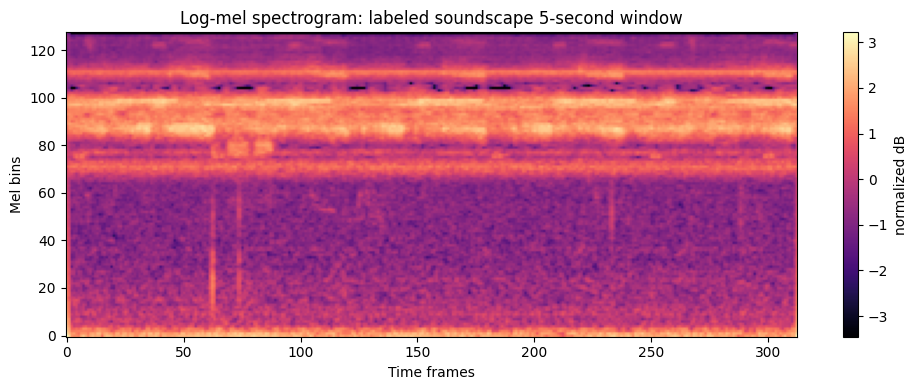

In [15]:
if AUDIO_BACKEND is None:
    print("Skipping soundscape preprocessing demo because no audio backend is installed.")
else:
    example_soundscape_row = soundscape_manifest[soundscape_manifest["file_exists"]].sample(1, random_state=SEED).iloc[0]
    y = load_audio(
        example_soundscape_row["audio_path"],
        offset_seconds=float(example_soundscape_row["start_seconds"]),
        duration_seconds=CLIP_SECONDS,
    )
    logmel = normalize_logmel(waveform_to_logmel(y))

    print("Example soundscape:", example_soundscape_row["filename"])
    print("Window:", example_soundscape_row["start"], "to", example_soundscape_row["end"])
    print("Labels:", example_soundscape_row["labels_string"])
    print("Waveform shape:", y.shape)
    print("Log-mel shape:", logmel.shape)

    plt.figure(figsize=(10, 4))
    plt.imshow(logmel, aspect="auto", origin="lower", cmap="magma")
    plt.title("Log-mel spectrogram: labeled soundscape 5-second window")
    plt.xlabel("Time frames")
    plt.ylabel("Mel bins")
    plt.colorbar(label="normalized dB")
    plt.tight_layout()
    plt.show()

## 11. Create Small Example Feature Batches

This cell saves tiny `.npz` batches so we can verify shapes before training. It is intentionally small. For full model training, we can either compute spectrograms on the fly inside a PyTorch `Dataset` or build a full cache later.

In [16]:
def make_train_audio_example_batch(n_examples=16):
    rows = train_audio_manifest[train_audio_manifest["file_exists"]].sample(n_examples, random_state=SEED)
    x_list = []
    y_list = []
    meta = []

    for _, row in rows.iterrows():
        waveform = load_audio(row["audio_path"], offset_seconds=0, duration_seconds=CLIP_SECONDS)
        logmel = normalize_logmel(waveform_to_logmel(waveform))
        x_list.append(logmel)
        y_list.append(labels_to_multihot(row["labels"]))
        meta.append({"filename": row["filename"], "primary_label": row["primary_label"], "common_name": row["common_name"]})

    return np.stack(x_list), np.stack(y_list), meta


def make_soundscape_example_batch(n_examples=16):
    rows = soundscape_manifest[soundscape_manifest["file_exists"]].sample(n_examples, random_state=SEED)
    x_list = []
    y_list = []
    meta = []

    for _, row in rows.iterrows():
        waveform = load_audio(row["audio_path"], offset_seconds=float(row["start_seconds"]), duration_seconds=CLIP_SECONDS)
        logmel = normalize_logmel(waveform_to_logmel(waveform))
        x_list.append(logmel)
        y_list.append(labels_to_multihot(row["labels"]))
        meta.append({"filename": row["filename"], "start": row["start"], "end": row["end"], "labels": row["labels_string"]})

    return np.stack(x_list), np.stack(y_list), meta


if AUDIO_BACKEND is None:
    print("Skipping example feature batch creation because no audio backend is installed.")
else:
    train_x, train_y, train_meta = make_train_audio_example_batch(n_examples=16)
    sound_x, sound_y, sound_meta = make_soundscape_example_batch(n_examples=16)

    train_batch_path = WORK_DIR / "example_train_audio_logmel_batch.npz"
    sound_batch_path = WORK_DIR / "example_soundscape_logmel_batch.npz"

    np.savez_compressed(train_batch_path, x=train_x, y=train_y, meta=json.dumps(train_meta))
    np.savez_compressed(sound_batch_path, x=sound_x, y=sound_y, meta=json.dumps(sound_meta))

    print("Saved:", train_batch_path)
    print("train_audio batch x/y:", train_x.shape, train_y.shape)
    print("Saved:", sound_batch_path)
    print("soundscape batch x/y:", sound_x.shape, sound_y.shape)

Saved: d:\BirdCLEF+\birdclef_work\example_train_audio_logmel_batch.npz
train_audio batch x/y: (16, 128, 313) (16, 234)
Saved: d:\BirdCLEF+\birdclef_work\example_soundscape_logmel_batch.npz
soundscape batch x/y: (16, 128, 313) (16, 234)


## 12. Optional: Full Cache Switch

Leave this off for now. The first training notebook can compute log-mels on the fly. If later we want faster repeated experiments, we can turn this into a full spectrogram cache.

In [17]:
BUILD_FULL_CACHE = False

if not BUILD_FULL_CACHE:
    print("Full spectrogram cache is disabled. This notebook has completed dataset prep and preprocessing validation.")
else:
    raise NotImplementedError(
        "Full cache generation is intentionally disabled for the first notebook. "
        "After we choose the training strategy, we can cache exactly the data format the model will consume."
    )

Full spectrogram cache is disabled. This notebook has completed dataset prep and preprocessing validation.


## Outputs Created

After running the notebook, check `birdclef_work/` for:

- `label_map.csv`: the 234-class target map in submission-column order.
- `train_audio_manifest.csv`: curated audio metadata with file paths and class indices.
- `train_soundscape_windows.csv`: labeled 5-second soundscape windows with 234 multi-hot target columns.
- `example_train_audio_logmel_batch.npz`: small spectrogram sanity-check batch, if an audio backend is installed.
- `example_soundscape_logmel_batch.npz`: small soundscape spectrogram sanity-check batch, if an audio backend is installed.